In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(0)

In [2]:
# generate data
class1 = np.random.randn(50, 2) + [2, 2]
class2 = np.random.randn(50, 2) + [-2, -2]

X = np.vstack((class1, class2))

# labels (reshape for matrix math)
y = np.hstack((np.ones(50), np.zeros(50))).reshape(-1, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (100, 2)
Shape of y: (100, 1)


In [3]:
# sigmoid activation
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# derivative of sigmoid
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

In [4]:
# network architecture
input_size = 2
hidden_size = 5
output_size = 1

# initialize weights randomly
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

learning_rate = 0.01
epochs = 1000

In [5]:
losses = []

for epoch in range(epochs):
    
    # -------- Forward Propagation --------
    
    z1 = np.dot(X, W1) + b1
    a1 = sigmoid(z1)
    
    z2 = np.dot(a1, W2) + b2
    y_pred = sigmoid(z2)
    
    # -------- Loss Calculation --------
    
    loss = np.mean((y - y_pred)**2)
    losses.append(loss)
    
    # -------- Backpropagation --------
    
    # output layer gradient
    d_loss_output = 2 * (y_pred - y) / y.shape[0]
    d_output_z2 = sigmoid_derivative(z2)
    
    d_z2 = d_loss_output * d_output_z2
    
    d_W2 = np.dot(a1.T, d_z2)
    d_b2 = np.sum(d_z2, axis=0, keepdims=True)
    
    # hidden layer gradient
    d_hidden = np.dot(d_z2, W2.T)
    d_hidden_z1 = sigmoid_derivative(z1)
    
    d_z1 = d_hidden * d_hidden_z1
    
    d_W1 = np.dot(X.T, d_z1)
    d_b1 = np.sum(d_z1, axis=0, keepdims=True)
    
    # -------- Update Weights --------
    
    W2 -= learning_rate * d_W2
    b2 -= learning_rate * d_b2
    
    W1 -= learning_rate * d_W1
    b1 -= learning_rate * d_b1
    
    # print loss sometimes
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")

Epoch 0, Loss: 0.4515
Epoch 200, Loss: 0.3206
Epoch 400, Loss: 0.2158
Epoch 600, Loss: 0.1503
Epoch 800, Loss: 0.1115


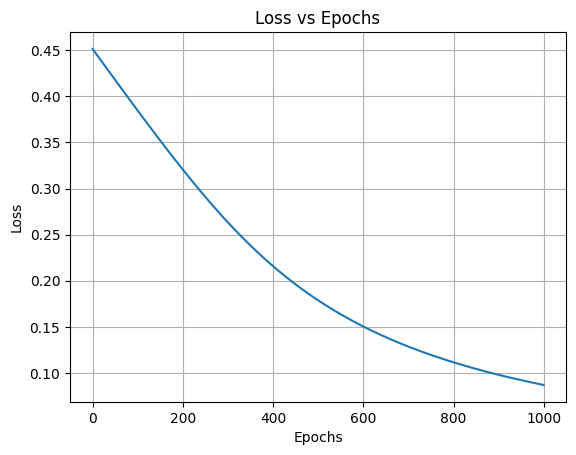

In [6]:
plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [7]:
# final prediction
final_output = sigmoid(np.dot(sigmoid(np.dot(X, W1) + b1), W2) + b2)

predictions = np.where(final_output >= 0.5, 1, 0)

accuracy = np.mean(predictions == y)

print("Training Accuracy:", accuracy)

Training Accuracy: 1.0
